# Boosting Models — AdaBoost, LightGBM, and CatBoost

**Author:** Shivani Bokka
**Datasets:** Adult Census Income (imbalanced binary classification), Ames Housing (regression)
**Goal:** Master boosting ensemble methods for production ML

---

## What Is This Notebook About?

This notebook is a **complete, production-ready walkthrough of boosting ensemble methods** — starting from the core intuition and building up to advanced topics like SHAP explainability, probability calibration, and model comparison.

Boosting is consistently one of the **top-performing families of algorithms** on structured/tabular data. If you work in industry with real datasets — income prediction, credit scoring, churn prediction, price forecasting — you will use boosting. This notebook will teach you not just *how* to use it, but *why* it works and *when* to pick each variant.

---

## Models and Topics Covered

| # | Topic | Key Idea |
|---|-------|----------|
| 1 | Imports and Setup | Environment and library setup |
| 2 | How Boosting Works | Manual walkthrough — residuals, weak learners |
| 3 | Load and Explore Data | Class imbalance visualization |
| 4 | Handling Class Imbalance | class_weight vs SMOTE comparison |
| 5 | AdaBoost | Weak learners, sample reweighting, staging scores |
| 6 | LightGBM | Leaf-wise growth, early stopping, training curves |
| 7 | CatBoost | Ordered boosting, native categorical handling |
| 8 | SHAP Values | Production-grade model explainability |
| 9 | Calibration Curves | Fixing overconfident probability estimates |
| 10 | Learning Curves | Diagnosing underfitting vs overfitting |
| 11 | Final Comparison | AdaBoost vs LightGBM vs CatBoost vs XGBoost |
| 12 | Summary | When to use each, common mistakes |

---

## Who Is This Notebook For?

Anyone who knows Python and basic machine learning but wants to go **deeper into boosting**. No prior knowledge of gradient boosting is assumed. Every section starts with plain English and builds to code.

---


## Step 1 — Imports and Setup

We import everything we'll need up front. A few notes:

- **lightgbm** — Microsoft's LightGBM library (install with `pip install lightgbm`)
- **catboost** — Yandex's CatBoost library (install with `pip install catboost`)
- **xgboost** — Chen & Guestrin's XGBoost (install with `pip install xgboost`)
- **shap** — Model explanation library (install with `pip install shap`)
- **imbalanced-learn** — Tools for handling class imbalance (install with `pip install imbalanced-learn`)

All random seeds are set to **42** throughout for reproducibility.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Datasets
from sklearn.datasets import fetch_openml

# Preprocessing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score,
    mean_squared_error, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Boosting models
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
import xgboost as xgb
from xgboost import XGBClassifier

# SHAP
import shap

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

print("All libraries imported successfully!")
print(f"LightGBM version: {lgb.__version__}")
print(f"XGBoost version:  {xgb.__version__}")


All libraries imported successfully!
LightGBM version: 4.6.0
XGBoost version:  3.2.0


---

## Step 2 — How Boosting Works (The Key Section)

Before writing a single line of model code, let's build a **deep intuition** for what boosting actually does. This section is worth reading carefully — everything else will make more sense after this.

---

### The Core Idea

> **Boosting is like a team of students where each new student focuses only on the questions the previous students got wrong.**

More precisely: boosting builds an **ensemble of weak learners** (simple models, often decision stumps) **sequentially**, where each new learner focuses on correcting the mistakes of all previous learners combined.

The final prediction is a **weighted combination** of all learners.

---

### AdaBoost vs Gradient Boosting — The Key Distinction

There are two main flavors of boosting, and confusing them is a common mistake:

| Aspect | AdaBoost | Gradient Boosting (GBM, XGBoost, LightGBM, CatBoost) |
|--------|----------|-------------------------------------------------------|
| What it corrects | Misclassified **samples** (reweights them) | **Residuals** (the numerical error of previous predictions) |
| How it corrects | Increases sample weight for errors; trains next learner on reweighted data | Trains next learner to **directly predict the residual** |
| Loss function | Exponential loss (hardcoded) | Arbitrary differentiable loss (you choose it) |
| Sensitivity to outliers | Very high (outlier weights explode) | Moderate (depends on loss function) |
| Analogy | Teacher marks wrong answers; student focuses on those | Calculator finds the gap; next step closes the gap |

---

### Manual Walkthrough: Gradient Boosting on 5 Data Points

Let's walk through **3 iterations of gradient boosting** by hand on a tiny regression example. This is exactly what LightGBM and XGBoost do internally, just at much larger scale.

**Setup:** We have 5 data points with a single feature x and target y:

| Point | x | y (true) |
|-------|---|----------|
| 1 | 1 | 3.0 |
| 2 | 2 | 5.0 |
| 3 | 3 | 4.0 |
| 4 | 4 | 8.0 |
| 5 | 5 | 7.0 |

**Step 0 — Initial Prediction:** Start with the mean of y = (3+5+4+8+7)/5 = **5.4**

---

**Iteration 1:**
- Compute residuals (error = y_true − prediction): [-2.4, -0.4, -1.4, +2.6, +1.6]
- Train a tiny decision tree to predict these residuals
- Say the tree learns: "if x ≤ 3, predict −1.4; else predict +2.1"
- Update predictions: 5.4 + (0.1 × tree_prediction)
  - (learning_rate = 0.1 shrinks each step to prevent overfitting)
- New predictions: [5.26, 5.26, 5.26, 5.61, 5.61]

**Iteration 2:**
- New residuals: [-2.26, -0.26, -1.26, +2.39, +1.39]
- Train another tree on these new residuals
- Again update predictions with learning_rate × new_tree

**Iteration 3:**
- Residuals shrink further
- Each iteration closes the gap between prediction and truth

---

**Summary Table — How Predictions Improve:**

| Iteration | Point 1 Pred | Point 4 Pred | Point 1 Residual | Point 4 Residual |
|-----------|-------------|-------------|-----------------|------------------|
| 0 (mean)  | 5.40 | 5.40 | -2.40 | +2.60 |
| 1         | 5.26 | 5.61 | -2.26 | +2.39 |
| 2         | 5.13 | 5.82 | -2.13 | +2.18 |
| 3         | 5.02 | 6.00 | -2.02 | +2.00 |

Notice: each iteration, the predictions inch closer to the true values (3.0 for Point 1, 8.0 for Point 4). With hundreds of iterations, the predictions converge.

---

### Why This Works

Each tree only needs to be a **weak learner** (slightly better than random). The magic is in the **sequential accumulation** — many weak learners combined become a strong learner.

The key hyperparameters that control this process:
- **n_estimators** — how many trees to build (more = more capacity, but slower and can overfit)
- **learning_rate** — how much each tree contributes (smaller = more conservative, needs more trees)
- **max_depth / num_leaves** — how complex each individual tree is

> **Rule of thumb:** Small learning rate + many trees = better generalization, but slower. Use early stopping to find the right number of trees automatically.

---

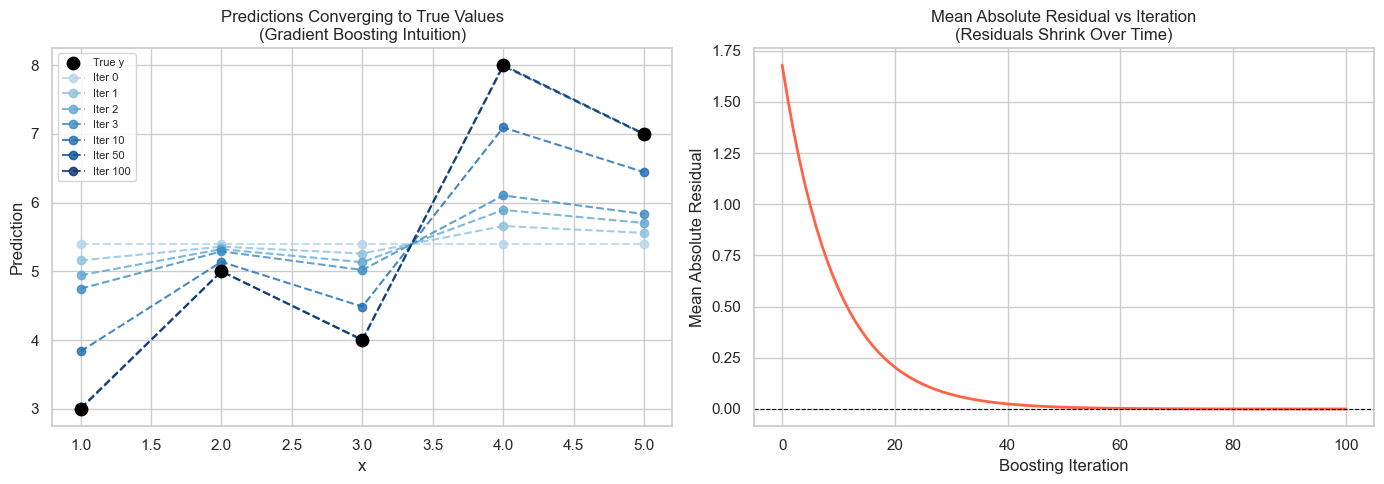

Boosting convergence demo complete.
Starting mean absolute error: 1.680
After 10 iterations:          0.586
After 100 iterations:         0.000


In [2]:
# Visualize the manual boosting walkthrough
iterations = [0, 1, 2, 3, 10, 50, 100]
x_pts = np.array([1, 2, 3, 4, 5])
y_true = np.array([3.0, 5.0, 4.0, 8.0, 7.0])

# Simulate gradient boosting manually with learning_rate=0.1
lr = 0.1
mean_pred = np.mean(y_true)

# We'll use a simple approximation: each iteration reduces residuals by a fraction
# (In real GBM, each tree fits the residuals)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: show how predictions converge
pred = np.full(5, mean_pred)
all_preds = [pred.copy()]
for i in range(100):
    residuals = y_true - pred
    pred = pred + lr * residuals
    all_preds.append(pred.copy())

axes[0].scatter(x_pts, y_true, color='black', zorder=5, s=80, label='True y')
colors = plt.cm.Blues(np.linspace(0.3, 1.0, len(iterations)))
for idx, (it, col) in enumerate(zip(iterations, colors)):
    axes[0].plot(x_pts, all_preds[it], 'o--', color=col, label=f'Iter {it}', alpha=0.8)
axes[0].set_title('Predictions Converging to True Values\n(Gradient Boosting Intuition)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Prediction')
axes[0].legend(fontsize=8)

# Right: show residuals shrinking
residual_sizes = [np.mean(np.abs(y_true - p)) for p in all_preds]
axes[1].plot(range(len(residual_sizes)), residual_sizes, color='tomato', linewidth=2)
axes[1].set_title('Mean Absolute Residual vs Iteration\n(Residuals Shrink Over Time)')
axes[1].set_xlabel('Boosting Iteration')
axes[1].set_ylabel('Mean Absolute Residual')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print("Boosting convergence demo complete.")
print(f"Starting mean absolute error: {residual_sizes[0]:.3f}")
print(f"After 10 iterations:          {residual_sizes[10]:.3f}")
print(f"After 100 iterations:         {residual_sizes[100]:.3f}")

### How to Read This Chart: Boosting Convergence

**Left panel — Predictions converging to true values:**
- **Black dots** are the true y values for our 5 toy data points.
- **Each colored line** is the model's prediction after a certain number of boosting iterations.
- **Lighter blue = earlier iterations** (further from truth); **Darker blue = later iterations** (closer to truth).
- Watch how the prediction line moves *toward* the black dots as iterations increase. This is literally what gradient boosting does — each iteration moves the prediction a small step in the right direction.

**Right panel — Residuals shrinking:**
- The **y-axis** is the mean absolute residual (average error across all 5 points).
- The **x-axis** is the number of boosting iterations.
- The curve shows **exponential decay** — big improvements early, diminishing returns later.
- This is why learning curves plateau: the easy errors are fixed first, and only the hard ones remain.

> **Key insight:** Gradient boosting is just iterative residual fitting. Each tree is tiny and weak. The power comes from stacking hundreds of them. The learning rate controls how cautiously we step — smaller steps need more trees but generalize better.

---

---

## Step 3 — Load and Explore Data

### Dataset 1: Adult Census Income (Imbalanced Binary Classification)

We use the **Adult Census Income** dataset (1994 US Census): ~48,800 people described by
demographic and employment features. The goal is to **predict whether a person earns more
than \$50K per year**. About **24% of people earn >50K**, so this is a *moderately imbalanced*
problem — enough to make imbalance handling matter, without being as extreme as fraud (<1%).

**Why class imbalance matters:**
- If 76% of people earn ≤50K, a model that always predicts "≤50K" gets 76% accuracy — but catches **zero** high earners.
- Standard accuracy is **misleading** for imbalanced problems. We track precision, recall, and F1 on the *minority* (>50K) class.

> **Two encodings.** Most libraries (LightGBM, AdaBoost, XGBoost) need numeric input, so we
> ordinal-encode the categorical columns. CatBoost can consume the **raw** categorical columns
> directly, so we keep an un-encoded copy too — this is exactly what we demonstrate in Step 7.

### Dataset 2: Ames Housing (Regression)

We also load the **Ames Housing** dataset (house sales in Ames, Iowa — sale price in dollars)
for the regression sections (LightGBM regression, SHAP values).

---


In [3]:
# ── Dataset 1: Adult Census Income (imbalanced classification) ───────────────
adult_raw = fetch_openml('adult', version=2, as_frame=True).frame

# Drop redundant / non-predictive columns
adult = adult_raw.drop(columns=['fnlwgt', 'education']).copy()

# Target: 1 if the person earns >50K, else 0
y_income = (adult['class'].astype(str) == '>50K').astype(int).values
adult_features = adult.drop(columns=['class'])

cat_cols_adult = adult_features.select_dtypes(exclude='number').columns.tolist()

# RAW version (string categoricals) — for CatBoost's native categorical handling (Step 7)
X_raw = adult_features.copy()
for c in cat_cols_adult:
    X_raw[c] = X_raw[c].astype(str)

# ENCODED version (ordinal codes) — for LightGBM / AdaBoost / XGBoost / SMOTE
X_enc = adult_features.copy()
for c in cat_cols_adult:
    X_enc[c] = X_enc[c].astype('category').cat.codes

# Class distribution (full data)
unique, counts = np.unique(y_income, return_counts=True)
class_dist = dict(zip(unique.tolist(), counts.tolist()))
print(f"Class distribution: {class_dist}")
minority_pct = counts[1] / counts.sum() * 100
print(f"Minority class (>50K): {minority_pct:.2f}% of all samples")

# Encoded split — used by most models below
X_tr, X_te, y_tr, y_te = train_test_split(
    X_enc, y_income, test_size=0.2, random_state=42, stratify=y_income
)
# Aligned raw split — same partition (same seed/stratify) — used only for CatBoost
Xr_tr, Xr_te, _, _ = train_test_split(
    X_raw, y_income, test_size=0.2, random_state=42, stratify=y_income
)

print(f"\nTrain size: {X_tr.shape[0]} | Test size: {X_te.shape[0]}")
print(f"Train >50K count: {y_tr.sum()} | Test >50K count: {y_te.sum()}")


Class distribution: {0: 37155, 1: 11687}
Minority class (>50K): 23.93% of all samples

Train size: 39073 | Test size: 9769
Train >50K count: 9349 | Test >50K count: 2338


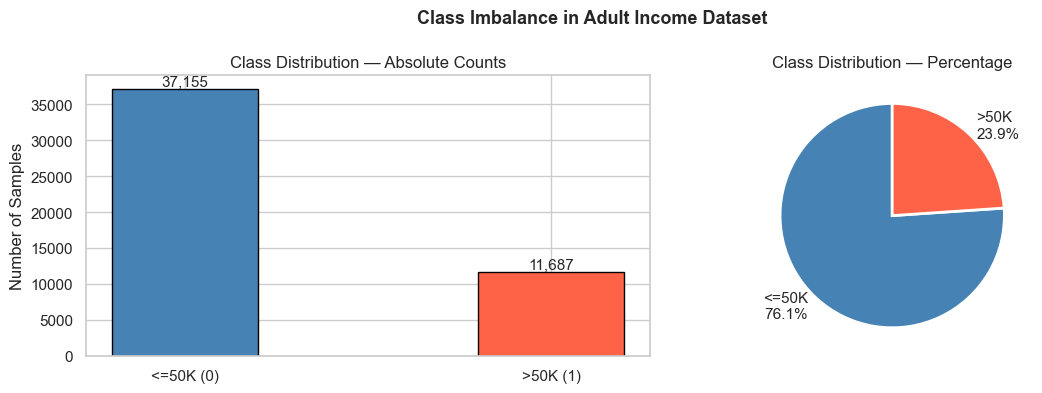

In [4]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
labels = ['<=50K (0)', '>50K (1)']
bars = axes[0].bar(labels, counts, color=['steelblue', 'tomato'], edgecolor='black', width=0.4)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Class Distribution — Absolute Counts')
axes[0].set_ylabel('Number of Samples')

# Pie chart
pct = counts / counts.sum() * 100
axes[1].pie(pct, labels=[f'<=50K\n{pct[0]:.1f}%', f'>50K\n{pct[1]:.1f}%'],
            colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution — Percentage')

plt.suptitle('Class Imbalance in Adult Income Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### How to Read This Chart: Class Imbalance

**Left panel — Bar chart:**
- The bars show the raw count of each class. About three times as many people earn ≤50K as >50K.
- The numbers on top of each bar show the exact counts.

**Right panel — Pie chart:**
- The pie chart shows the percentage breakdown — roughly 76% / 24%.
- The >50K slice is the minority. The model sees fewer high-earner examples during training, so it learns less about them.

**Why this matters — the accuracy trap:**
- Here, a model that *always* predicts "≤50K" achieves **~76% accuracy**.
- That sounds okay — but it catches exactly **zero** high earners. It is useless for the task we actually care about.
- This is why we use **precision, recall, and F1 on the minority (>50K) class** instead of accuracy.

> **Note on severity.** Adult is *moderately* imbalanced (~24% positive). The techniques below
> still help here, but they matter far more as imbalance grows — on true fraud data (<1% positive)
> they are the difference between a working model and a useless one.

**Three strategies to handle imbalance (covered in Step 4):**
1. `class_weight='balanced'` — tells the model to penalize minority class errors more
2. SMOTE — synthetically generates new minority class examples
3. Threshold tuning — adjust the decision threshold from 0.5 to something better

---


In [5]:
# ── Dataset 2: Ames Housing (regression) ─────────────────────────────────────
ames_raw = fetch_openml('house_prices', as_frame=True).frame

y_house = ames_raw['SalePrice'].astype(float)
X_house = ames_raw.drop(columns=['SalePrice', 'Id'], errors='ignore').copy()

# Same preprocessing recipe as notebook 01: median-impute numeric, ordinal-encode categoricals
num_cols = X_house.select_dtypes(include='number').columns
cat_cols = X_house.select_dtypes(exclude='number').columns
X_house[num_cols] = X_house[num_cols].fillna(X_house[num_cols].median())
for c in cat_cols:
    X_house[c] = X_house[c].astype('object').fillna('None').astype('category').cat.codes

print("Ames Housing Dataset")
print(f"Shape: {X_house.shape}")
print(f"Sale price range: ${y_house.min():,.0f} - ${y_house.max():,.0f}")
print("\nFirst 3 rows:")
display(X_house.head(3))

X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)
print(f"\nHousing train: {X_h_tr.shape} | test: {X_h_te.shape}")


Ames Housing Dataset
Shape: (1460, 79)
Sale price range: $34,900 - $755,000

First 3 rows:


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0000,8450,1,1,3,3,0,4,...,0,0,3,4,1,0,2,2008,8,4
1,20,3,80.0000,9600,1,1,3,3,0,2,...,0,0,3,4,1,0,5,2007,8,4
2,60,3,68.0000,11250,1,1,0,3,0,4,...,0,0,3,4,1,0,9,2008,8,4



Housing train: (1168, 79) | test: (292, 79)


---

## Step 4 — Handling Class Imbalance: class_weight vs SMOTE

There is no single best approach to imbalance — the right choice depends on your data and business goal. Here we compare three approaches head-to-head:

1. **No handling** — train as-is, let the model be biased toward the majority class
2. **class_weight='balanced'** — tells LightGBM to give minority class errors more weight during training (simple and often effective)
3. **SMOTE (Synthetic Minority Oversampling Technique)** — generates synthetic minority class samples by interpolating between existing ones

### How SMOTE Works (Briefly)

SMOTE selects a minority class sample, finds its k nearest neighbors (also minority class), and creates new synthetic samples along the line between them. It does **not** just duplicate — it creates *new* points in feature space.

> **Warning:** SMOTE must only be applied to the **training set**. Never apply it before splitting, or you'll leak synthetic test samples into training — a form of data leakage.

---

In [6]:
from sklearn.metrics import classification_report

def report_metrics(name, y_true, y_pred, y_prob=None):
    """Return a dict of metrics for the minority class."""
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    auc   = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    return {'Model': name, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc}

imbalance_results = []

# ── 1. No handling ──────────────────────────────────────────────────────────
lgb_no_handling = LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
lgb_no_handling.fit(X_tr, y_tr)
pred_no = lgb_no_handling.predict(X_te)
prob_no = lgb_no_handling.predict_proba(X_te)[:, 1]
imbalance_results.append(report_metrics('No Handling', y_te, pred_no, prob_no))
print("--- No Handling ---")
print(classification_report(y_te, pred_no, target_names=['<=50K', '>50K']))

# ── 2. class_weight='balanced' ──────────────────────────────────────────────
lgb_balanced = LGBMClassifier(
    n_estimators=200, random_state=42, verbose=-1,
    class_weight='balanced'
)
lgb_balanced.fit(X_tr, y_tr)
pred_bal = lgb_balanced.predict(X_te)
prob_bal = lgb_balanced.predict_proba(X_te)[:, 1]
imbalance_results.append(report_metrics('class_weight balanced', y_te, pred_bal, prob_bal))
print("--- class_weight='balanced' ---")
print(classification_report(y_te, pred_bal, target_names=['<=50K', '>50K']))

# ── 3. SMOTE ────────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)
print(f"After SMOTE — train shape: {X_tr_sm.shape}, >50K count: {y_tr_sm.sum()}")

lgb_smote = LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
lgb_smote.fit(X_tr_sm, y_tr_sm)
pred_sm = lgb_smote.predict(X_te)
prob_sm = lgb_smote.predict_proba(X_te)[:, 1]
imbalance_results.append(report_metrics('SMOTE', y_te, pred_sm, prob_sm))
print("--- SMOTE ---")
print(classification_report(y_te, pred_sm, target_names=['<=50K', '>50K']))

--- No Handling ---
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      7431
        >50K       0.79      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



--- class_weight='balanced' ---
              precision    recall  f1-score   support

       <=50K       0.95      0.83      0.88      7431
        >50K       0.61      0.86      0.71      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.84      0.80      9769
weighted avg       0.87      0.84      0.84      9769



After SMOTE — train shape: (59448, 12), >50K count: 29724


--- SMOTE ---
              precision    recall  f1-score   support

       <=50K       0.94      0.85      0.90      7431
        >50K       0.64      0.83      0.72      2338

    accuracy                           0.85      9769
   macro avg       0.79      0.84      0.81      9769
weighted avg       0.87      0.85      0.85      9769




Summary comparison (minority class metrics):


,Precision,Recall,F1,AUC
Model,,,,
No Handling,0.7895,0.6561,0.7167,0.9309
class_weight balanced,0.6112,0.8567,0.7134,0.9295
SMOTE,0.6424,0.8298,0.7242,0.9264


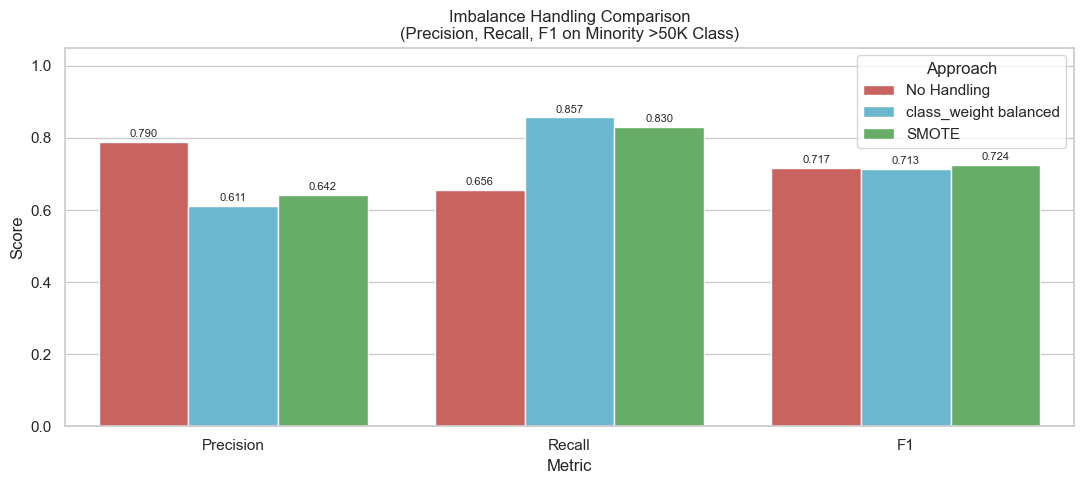

In [7]:
# Side-by-side comparison chart
df_imb = pd.DataFrame(imbalance_results)
print("\nSummary comparison (minority class metrics):")
display(df_imb.set_index('Model').round(4))

df_plot = df_imb.melt(id_vars='Model', value_vars=['Precision', 'Recall', 'F1'],
                      var_name='Metric', value_name='Score')

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=df_plot, x='Metric', y='Score', hue='Model',
                 palette=['#d9534f', '#5bc0de', '#5cb85c'])
plt.title('Imbalance Handling Comparison\n(Precision, Recall, F1 on Minority >50K Class)',
          fontsize=12)
plt.ylim(0, 1.05)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.legend(title='Approach')
plt.tight_layout()
plt.show()

### How to Read This Chart: Precision-Recall Tradeoff

This **grouped bar chart** compares three imbalance-handling approaches across three metrics for the **minority (>50K) class**.

**The three metrics explained:**
- **Precision** — of all people predicted as >50K, what fraction actually earn >50K? High precision = few false alarms.
- **Recall** — of all people who actually earn >50K, what fraction did the model catch? High recall = few missed positives.
- **F1** — harmonic mean of precision and recall. Balances both concerns.

**The fundamental tradeoff:**
- Improving recall (catching more of the minority class) usually decreases precision (more false alarms).
- The right balance depends on your business: missing high earners (low recall) may lose opportunities; too many false positives (low precision) wastes follow-up effort.

**What to look for:**
- "No Handling" typically has high precision but low recall — the model is conservative about predicting the minority class.
- `class_weight='balanced'` and SMOTE both push recall up, but may sacrifice some precision.
- SMOTE often works well when the minority class is very small; class_weight is simpler and faster.

**When to use each:**
- `class_weight='balanced'` — first choice; fast, no data modification, often good enough
- SMOTE — when imbalance is extreme (>100:1) and class_weight doesn't improve recall enough
- Threshold tuning — not shown here, but powerful: lower the decision threshold from 0.5 to 0.2-0.3 to catch more of the minority class

---

---

## Step 5 — AdaBoost

### What Is AdaBoost?

**AdaBoost (Adaptive Boosting)** was one of the first practical boosting algorithms (Freund & Schapire, 1997). It is elegant in its simplicity:

1. **Start** with equal weights on all training samples
2. **Train** a weak learner (typically a decision stump — a tree with depth=1)
3. **Compute error** — the weighted misclassification rate
4. **Assign weight to this learner** — better learners get more vote
5. **Reweight samples** — increase weights on misclassified samples (so the next learner focuses on them)
6. **Repeat** for N iterations
7. **Final prediction** = weighted majority vote of all learners

### Weak Learners (Stumps)

A **decision stump** is the simplest possible decision tree — it splits on exactly one feature and makes one split. Each stump is barely better than random, but 200 stumps together can be remarkably powerful.

> **Analogy:** Each student (stump) only knows one thing. But 200 specialized students, each focused on a different aspect of the problem, can collectively answer any question.

### Key Difference from Gradient Boosting

- AdaBoost **reweights samples** — it tells the next learner "pay more attention to these examples"
- Gradient Boosting **fits residuals** — it tells the next learner "predict the remaining error directly"

AdaBoost is more sensitive to outliers (a single mislabeled hard sample can dominate the weights) but is simpler and works well on clean data.

---

In [8]:
# Train AdaBoost on Adult income data
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # weak learner = stump
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_tr, y_tr)
pred_ada = ada.predict(X_te)
prob_ada = ada.predict_proba(X_te)[:, 1]

auc_ada = roc_auc_score(y_te, prob_ada)
f1_ada  = f1_score(y_te, pred_ada, zero_division=0)

print("AdaBoost Results")
print("="*40)
print(classification_report(y_te, pred_ada, target_names=['<=50K', '>50K']))
print(f"AUC: {auc_ada:.4f}")

AdaBoost Results
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      7431
        >50K       0.79      0.55      0.65      2338

    accuracy                           0.86      9769
   macro avg       0.83      0.75      0.78      9769
weighted avg       0.85      0.86      0.85      9769

AUC: 0.9101


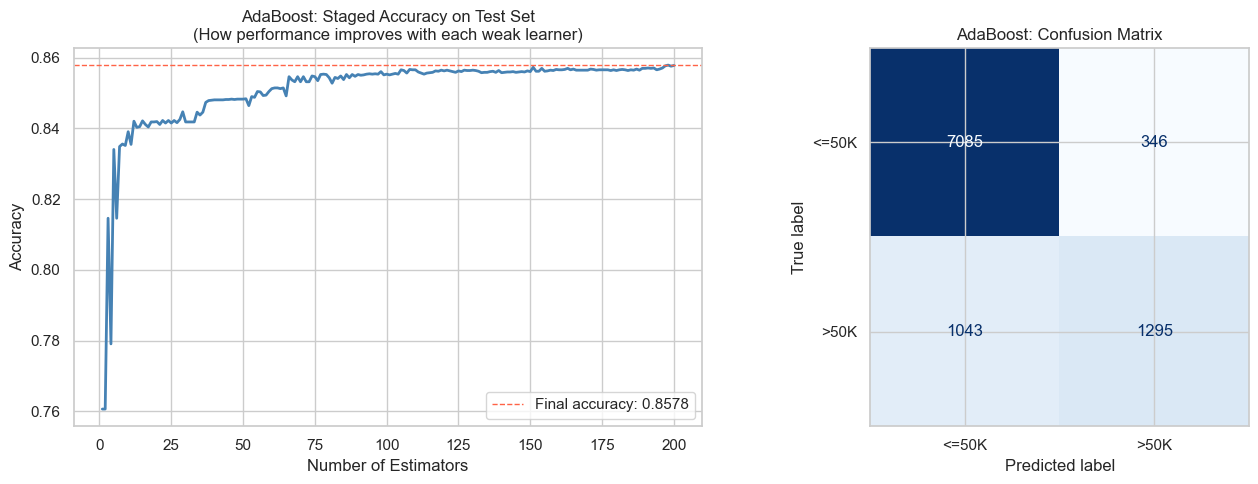

In [9]:
# Plot: staging scores (how estimator error changes with each tree)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: staged test score (accuracy) over number of estimators
staged_scores = list(ada.staged_score(X_te, y_te))
axes[0].plot(range(1, len(staged_scores)+1), staged_scores,
             color='steelblue', linewidth=2)
axes[0].set_title('AdaBoost: Staged Accuracy on Test Set\n(How performance improves with each weak learner)')
axes[0].set_xlabel('Number of Estimators')
axes[0].set_ylabel('Accuracy')
axes[0].axhline(staged_scores[-1], color='tomato', linestyle='--', linewidth=1,
                label=f'Final accuracy: {staged_scores[-1]:.4f}')
axes[0].legend()

# Right: confusion matrix
cm = confusion_matrix(y_te, pred_ada)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('AdaBoost: Confusion Matrix')

plt.tight_layout()
plt.show()

### How to Read This Chart: AdaBoost Staging

**Left panel — Staged Accuracy:**
- The **x-axis** is the number of weak learners (stumps) used in the ensemble.
- The **y-axis** is the test accuracy at that point.
- Watch how accuracy **jumps quickly at first** (adding the first few stumps makes a huge difference) then **plateaus** as the ensemble becomes saturated.
- The **red dashed line** marks the final accuracy with all 200 estimators.

**What "estimator error" means:** Each individual stump has a weighted error rate (how many reweighted samples it misclassifies). A stump with error > 0.5 is worse than random and gets negative weight — effectively flipping its vote. A perfect stump (error=0) gets infinite weight. In practice, good stumps have error around 0.3–0.45.

**When staging plateaus:**
- If the curve stops improving at e.g., iteration 50, adding more estimators wastes compute.
- The plateau tells you the optimal n_estimators — a key hyperparameter to tune.

**Right panel — Confusion Matrix:**
- Rows = true class; Columns = predicted class
- **Top-left (TN)** = correctly predicted <=50K
- **Bottom-right (TP)** = correctly predicted >50K — the minority class we care about
- **Top-right (FP)** = <=50K predicted as >50K (false positive)
- **Bottom-left (FN)** = a >50K earner missed (false negative)

---

---

## Step 6 — LightGBM

### What Makes LightGBM Special?

**LightGBM** (Light Gradient Boosting Machine, Microsoft 2017) is the industry standard for tabular data problems. It's fast, memory-efficient, and achieves state-of-the-art results on structured data.

### Key Innovation 1: Leaf-Wise Growth (vs Level-Wise)

Most gradient boosting implementations grow trees **level by level** — they add a full row of nodes across the entire tree before going deeper. LightGBM uses **leaf-wise** growth:

- At each step, it identifies the **single leaf with the highest potential gain** and splits only that leaf.
- This creates **asymmetric, deeper trees** that can model complex patterns better.
- It's more accurate per tree but needs `num_leaves` to be carefully controlled (too high → overfit).

```
Level-wise:          Leaf-wise:
      R                  R
     / \                / \
    A   B              A   B
   / \ / \                / \
  C  D E  F              E   F
                              \
                               G
```

### Key Innovation 2: Gradient-Based One-Side Sampling (GOSS)

LightGBM doesn't use all data for every split decision. It keeps samples with **large gradients** (hard examples) and randomly samples those with small gradients (easy examples). This speeds up training by 10-20x.

### Key Innovation 3: Exclusive Feature Bundling (EFB)

For sparse/one-hot encoded features, LightGBM bundles mutually exclusive features together, reducing the effective number of features.

---

In [10]:
# LightGBM with early stopping on Adult income classification
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_tr, y_tr, test_size=0.15, random_state=42, stratify=y_tr
)

lgb_clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

# Early stopping: stop if val log_loss doesn't improve for 30 rounds
lgb_clf.fit(
    X_tr2, y_tr2,
    eval_set=[(X_tr2, y_tr2), (X_val, y_val)],
    eval_metric='binary_logloss',
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.record_evaluation(evals_result := {})
    ]
)

best_iter = lgb_clf.best_iteration_
print(f"Best iteration (early stopping): {best_iter}")

pred_lgb = lgb_clf.predict(X_te)
prob_lgb = lgb_clf.predict_proba(X_te)[:, 1]
auc_lgb = roc_auc_score(y_te, prob_lgb)
print(f"\nLightGBM (income classification)")
print(classification_report(y_te, pred_lgb, target_names=['<=50K', '>50K']))
print(f"AUC: {auc_lgb:.4f}")

Best iteration (early stopping): 483

LightGBM (income classification)
              precision    recall  f1-score   support

       <=50K       0.95      0.83      0.88      7431
        >50K       0.61      0.85      0.71      2338

    accuracy                           0.83      9769
   macro avg       0.78      0.84      0.80      9769
weighted avg       0.87      0.83      0.84      9769

AUC: 0.9285


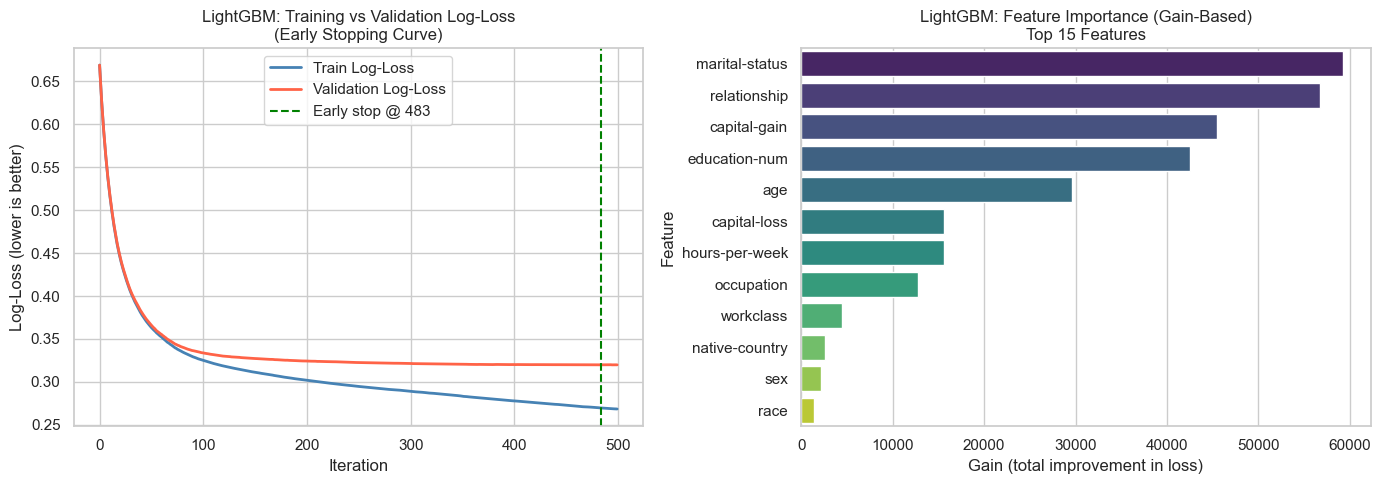

In [11]:
# Plot training vs validation log_loss curves
train_loss = evals_result['training']['binary_logloss']
val_loss   = evals_result['valid_1']['binary_logloss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_loss, label='Train Log-Loss', color='steelblue', linewidth=2)
axes[0].plot(val_loss, label='Validation Log-Loss', color='tomato', linewidth=2)
axes[0].axvline(best_iter, color='green', linestyle='--', linewidth=1.5,
                label=f'Early stop @ {best_iter}')
axes[0].set_title('LightGBM: Training vs Validation Log-Loss\n(Early Stopping Curve)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Log-Loss (lower is better)')
axes[0].legend()

# Feature importance (gain-based)
importance = lgb_clf.booster_.feature_importance(importance_type='gain')
feat_names = list(X_tr.columns)
fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': importance})
fi_df = fi_df.sort_values('Importance', ascending=False).head(15)

sns.barplot(data=fi_df, x='Importance', y='Feature', ax=axes[1],
            palette='viridis')
axes[1].set_title('LightGBM: Feature Importance (Gain-Based)\nTop 15 Features')
axes[1].set_xlabel('Gain (total improvement in loss)')

plt.tight_layout()
plt.show()

### How to Read This Chart: LightGBM Training Curves

**Left panel — Loss Curves:**
- The **x-axis** is the boosting iteration (tree number).
- The **y-axis** is log-loss (lower = better predictions).
- **Blue line (train)** always decreases — the model keeps fitting training data better.
- **Red line (validation)** decreases initially, then **flattens or rises** — this is the model starting to overfit.
- **Green dashed line** = where early stopping triggered. At this point, validation loss stopped improving for 30 rounds.

**What early stopping does:** It automatically finds the iteration where the model generalizes best, preventing overfitting without manual tuning. After training, `lgb_clf.best_iteration_` gives you this number.

**Why val loss can rise while train loss still drops:** The model is memorizing training-specific patterns (noise, outliers) that don't exist in the real data. This is the classic signature of overfitting.

**Right panel — Feature Importance (Gain):**
- Each bar shows how much total improvement in the loss function this feature contributed across all splits.
- **Gain-based importance** is more reliable than split-count importance (which can be inflated by features with many unique values).
- The top feature contributes far more than the bottom ones — typical of real-world datasets where a few features dominate.

---

In [12]:
# LightGBM for regression on Ames Housing
lgb_reg = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

X_h_tr2, X_h_val, y_h_tr2, y_h_val = train_test_split(
    X_h_tr, y_h_tr, test_size=0.15, random_state=42
)

evals_house = {}
lgb_reg.fit(
    X_h_tr2, y_h_tr2,
    eval_set=[(X_h_tr2, y_h_tr2), (X_h_val, y_h_val)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.record_evaluation(evals_house)
    ]
)

pred_h_lgb = lgb_reg.predict(X_h_te)
rmse_lgb = np.sqrt(mean_squared_error(y_h_te, pred_h_lgb))
print(f"LightGBM Regression — Ames Housing")
print(f"RMSE: ${rmse_lgb:,.0f}  (sale price in US dollars)")
print(f"Best iteration: {lgb_reg.best_iteration_}")

LightGBM Regression — Ames Housing
RMSE: $29,564  (sale price in US dollars)
Best iteration: 121


---

## Step 7 — CatBoost

### What Makes CatBoost Special?

**CatBoost** (Categorical Boosting, Yandex 2017) solves two critical problems that plague other boosting libraries:

### Innovation 1: Ordered Boosting

Standard gradient boosting has a subtle data leakage problem. When computing gradients for sample $i$, it uses a model trained on data that *includes* sample $i$ — so the model has already "seen" that sample. This causes a small but consistent bias.

CatBoost uses **ordered boosting**: for each sample $i$, it builds a model using only the first $i-1$ samples. This eliminates the bias and improves generalization, especially on small datasets.

### Innovation 2: Native Categorical Handling

Most ML libraries require you to encode categorical variables before training (one-hot encoding, label encoding, etc.). **CatBoost handles raw categorical columns natively** — you just tell it which columns are categorical.

Under the hood, CatBoost converts categoricals to numbers using **target statistics** (a form of target encoding) but does it in an ordered, leak-free way.

**This is a big deal for production:** Real datasets often have many categorical features (customer IDs, product categories, city names). With CatBoost, you skip entire data preprocessing pipelines.

### When to Choose CatBoost Over LightGBM

| Scenario | Recommendation |
|----------|---------------|
| Many categorical features | **CatBoost** (no encoding needed) |
| Fastest training / largest datasets | **LightGBM** |
| Small dataset, high accuracy needed | **CatBoost** (ordered boosting helps) |
| Need GPU support | Both support GPU |
| Quick baseline on numeric data | **LightGBM** |

---

In [13]:
# ── CatBoost's native categorical handling, demonstrated for real ────────────
# Most libraries need categoricals encoded to numbers first. CatBoost consumes the
# RAW string columns directly — you just tell it which columns are categorical.
# We use the raw Adult split (Xr_tr / Xr_te) built in Step 3.

print("Raw categorical columns CatBoost will handle natively (no encoding):")
print(cat_cols_adult)
print()
print("A few raw rows (note the string categories — no label/one-hot encoding applied):")
display(Xr_tr[cat_cols_adult].head(3))
print(f"\nCatBoost gets cat_features={cat_cols_adult}")
print("LightGBM / AdaBoost / XGBoost, by contrast, use the ordinal-encoded X_tr / X_te.")


Raw categorical columns CatBoost will handle natively (no encoding):
['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

A few raw rows (note the string categories — no label/one-hot encoding applied):


,workclass,marital-status,occupation,relationship,race,sex,native-country
34342,Private,Never-married,Handlers-cleaners,Not-in-family,White,Male,United-States
18559,Private,Never-married,Sales,Other-relative,White,Female,United-States
12477,Private,Married-civ-spouse,Other-service,Husband,White,Male,El-Salvador



CatBoost gets cat_features=['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
LightGBM / AdaBoost / XGBoost, by contrast, use the ordinal-encoded X_tr / X_te.


In [14]:
# ── Train CatBoost on RAW Adult using native categorical handling ────────────
# Split the raw training data for early stopping (aligned seed keeps it comparable).
Xr_tr2, Xr_val, yr_tr2, yr_val = train_test_split(
    Xr_tr, y_tr, test_size=0.15, random_state=42, stratify=y_tr
)

cat_clf = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0
)
# Pass the categorical column names directly — no encoding pipeline needed.
cat_clf.fit(Xr_tr2, yr_tr2, cat_features=cat_cols_adult,
            eval_set=(Xr_val, yr_val), early_stopping_rounds=30)

pred_cat = cat_clf.predict(Xr_te).astype(int).ravel()
prob_cat = cat_clf.predict_proba(Xr_te)[:, 1]
auc_cat = roc_auc_score(y_te, prob_cat)

print("CatBoost Results (income classification, native categoricals):")
print("="*55)
print(classification_report(y_te, pred_cat, target_names=['<=50K', '>50K']))
print(f"AUC: {auc_cat:.4f}")


CatBoost Results (income classification, native categoricals):
              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88      7431
        >50K       0.60      0.86      0.71      2338

    accuracy                           0.83      9769
   macro avg       0.78      0.84      0.80      9769
weighted avg       0.87      0.83      0.84      9769

AUC: 0.9278


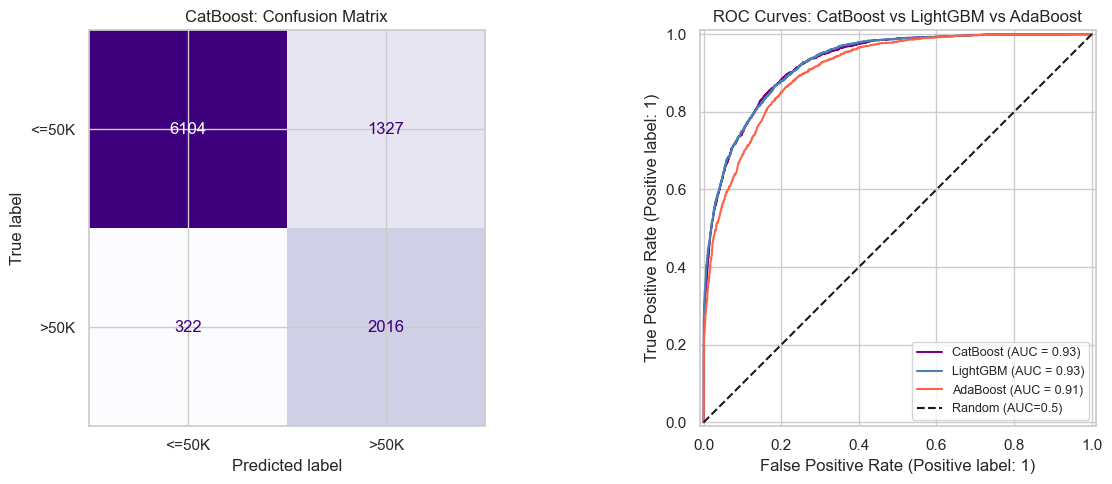

In [15]:
# Confusion matrix + AUC plot for CatBoost
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm_cat = confusion_matrix(y_te, pred_cat)
ConfusionMatrixDisplay(cm_cat, display_labels=['<=50K', '>50K']).plot(
    ax=axes[0], colorbar=False, cmap='Purples'
)
axes[0].set_title('CatBoost: Confusion Matrix')

# ROC AUC curve for CatBoost vs LightGBM
RocCurveDisplay.from_predictions(y_te, prob_cat, name='CatBoost', ax=axes[1],
                                  color='purple')
RocCurveDisplay.from_predictions(y_te, prob_lgb, name='LightGBM', ax=axes[1],
                                  color='steelblue')
RocCurveDisplay.from_predictions(y_te, prob_ada, name='AdaBoost', ax=axes[1],
                                  color='tomato')
axes[1].plot([0,1],[0,1],'k--', label='Random (AUC=0.5)')
axes[1].set_title('ROC Curves: CatBoost vs LightGBM vs AdaBoost')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

### How to Read This Chart: CatBoost vs LightGBM

**Left panel — Confusion Matrix:**
- Same interpretation as before. Focus on the bottom-right cell (>50K correctly caught) and bottom-left (>50K missed).
- Compare these numbers to AdaBoost's confusion matrix from Step 5 — is CatBoost catching more of the >50K class?

**Right panel — ROC Curves:**
- The **x-axis** is False Positive Rate (how often we falsely flag <=50K people as >50K).
- The **y-axis** is True Positive Rate = Recall (how often we correctly identify >50K earners).
- A **curve closer to the top-left corner** = better model (high recall without high false alarms).
- The **black dashed diagonal** = a random classifier (AUC=0.5, no skill).
- **AUC (Area Under Curve)** summarizes the entire curve in one number. AUC=1.0 = perfect; AUC=0.5 = random.

**When to choose CatBoost:**
- Your dataset has many string/categorical columns — CatBoost eliminates the need for encoding pipelines.
- Your dataset is small — ordered boosting reduces overfitting on small samples.
- You want very little preprocessing code in production.

**When to choose LightGBM:**
- Speed is critical (LightGBM is typically 5-10x faster than CatBoost).
- Your dataset is large (>1M rows) — LightGBM's GOSS sampling is a big win.
- Features are mostly numeric (CatBoost's categorical advantage doesn't apply).

---

---

## Step 8 — SHAP Values (The Most Important Production Section)

Training a model is only half the work. In production, stakeholders ask:
- "Why did the model predict this person earns >50K?"
- "What features drive house prices in our area?"
- "Can we trust this prediction?"

**SHAP (SHapley Additive exPlanations)** answers these questions rigorously.

### Why SHAP Is Better Than Feature Importance

**Standard feature importance** (split count, gain) tells you which features the model *uses most overall*. But it can't tell you:
- Does Feature X increase or decrease predictions?
- How does Feature X affect *this specific prediction*?
- Is Feature X's importance driven by high values or low values?

**SHAP** solves all of this. It's based on game theory (Shapley values from cooperative game theory) and has a rigorous mathematical guarantee: **SHAP values are the only consistent, locally accurate attribution method**.

The key idea: for each prediction, SHAP computes how much each feature *contributed* to the deviation from the base rate (average prediction). Positive SHAP = this feature pushed the prediction higher. Negative SHAP = pushed it lower.

### Three Views SHAP Gives You

1. **Beeswarm plot** — global view: how all features affect all predictions
2. **Waterfall plot** — local view: how each feature affected one specific prediction
3. **Bar plot of mean |SHAP|** — global importance (like feature importance, but signed and consistent)

---

In [16]:
# Train LightGBM on Ames Housing for SHAP analysis
lgb_shap = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
lgb_shap.fit(X_h_tr, y_h_tr)
pred_shap = lgb_shap.predict(X_h_te)
rmse_shap = np.sqrt(mean_squared_error(y_h_te, pred_shap))
print(f"LightGBM (for SHAP) — RMSE: {rmse_shap:.4f}")

# Compute SHAP values using TreeExplainer (fast for tree models)
print("\nComputing SHAP values with TreeExplainer...")
explainer = shap.TreeExplainer(lgb_shap)

# Use a subset for speed (SHAP can be slow on large datasets)
X_shap_sample = X_h_te.iloc[:500].copy()
shap_values = explainer(X_shap_sample)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Base value (average prediction): {shap_values.base_values[0]:.4f}")
print("Done.")

LightGBM (for SHAP) — RMSE: 29100.3883

Computing SHAP values with TreeExplainer...


SHAP values shape: (292, 79)
Base value (average prediction): 181441.5420
Done.


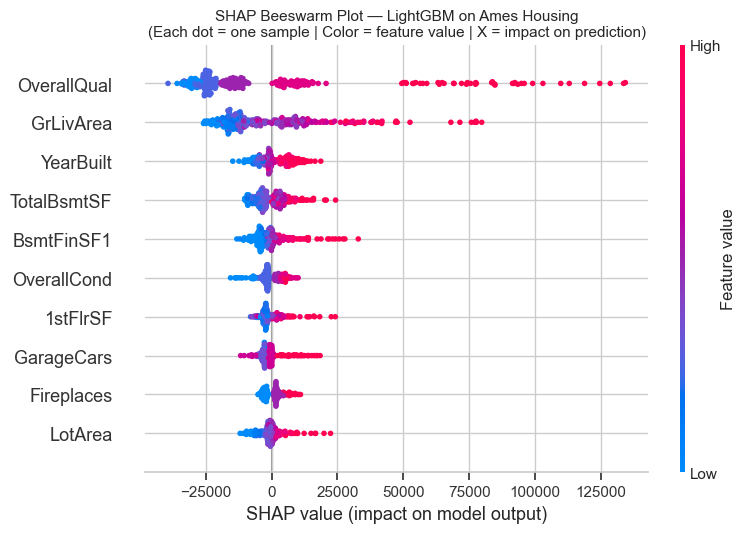

In [17]:
# Beeswarm plot — global view of all features
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_sample, plot_type='dot', show=False,
                  max_display=10)
plt.title('SHAP Beeswarm Plot — LightGBM on Ames Housing\n'
          '(Each dot = one sample | Color = feature value | X = impact on prediction)',
          fontsize=11)
plt.tight_layout()
plt.show()

### How to Read This Chart: SHAP Beeswarm Plot

This is the most information-dense chart SHAP produces. Here is a complete guide to every element:

**Structure:**
- **Each row** = one feature (sorted top-to-bottom by total importance)
- **Each dot** = one data sample (one house)
- **X-axis** = SHAP value = how much this feature pushed the prediction away from the base value
  - Positive SHAP → this feature *increased* the predicted sale price
  - Negative SHAP → this feature *decreased* the predicted price
  - SHAP=0 → this feature had no effect on this prediction
- **Color** = the actual value of that feature for that sample (red=high, blue=low)
- **Clustering** = multiple dots at the same x-position are stacked vertically (they're all at the same SHAP value)

**Reading a single row (example: OverallQual = overall quality rating):**
- Red dots (high quality) clustered on the right → high quality pushes prices UP (makes sense!)
- Blue dots (low quality) clustered on the left → low quality pushes prices DOWN
- The spread of the cluster shows how much this feature varies in impact

**What makes it better than bar chart importance:**
- You see the *direction* of the effect (does high value increase or decrease predictions?)
- You see the *distribution* (is the effect consistent or does it vary?)
- You can spot **non-linear relationships** (e.g., a feature where both very high and very low values push prediction down)

---


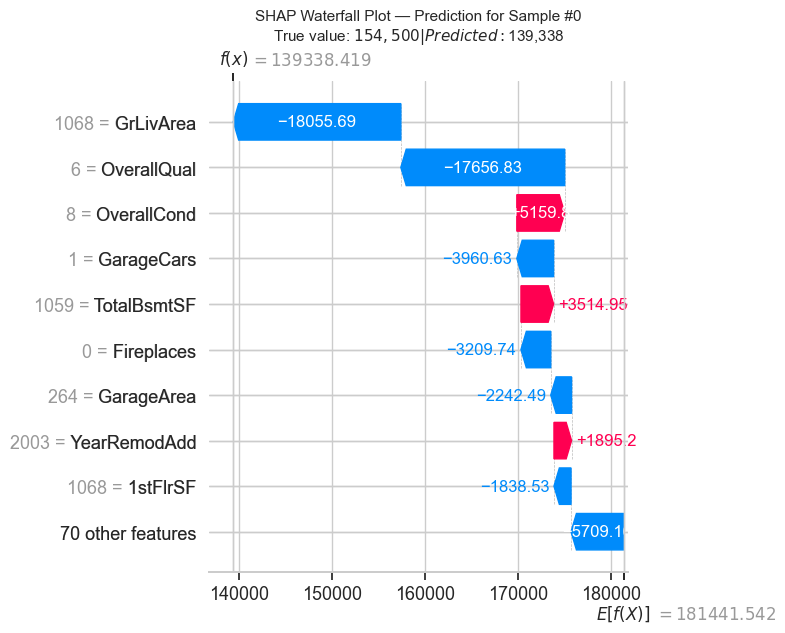


Detailed breakdown for sample #0:
  Base value (avg prediction): 181441.5420
  Model prediction:            139338.4189
  True value:                  154500.0000

  Top SHAP contributions:
  GrLivArea      : -18055.6932
  OverallQual    : -17656.8293
  OverallCond    : +5159.7971
  GarageCars     : -3960.6311
  TotalBsmtSF    : +3514.9544


In [18]:
# Waterfall plot — local explanation for one specific prediction
sample_idx = 0  # explain the first house in the sample
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_values[sample_idx], max_display=10, show=False)
plt.title(f'SHAP Waterfall Plot — Prediction for Sample #{sample_idx}\n'
          f'True value: ${y_h_te.iloc[sample_idx]:,.0f} | '
          f'Predicted: ${pred_shap[sample_idx]:,.0f}',
          fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nDetailed breakdown for sample #{sample_idx}:")
print(f"  Base value (avg prediction): {shap_values.base_values[sample_idx]:.4f}")
print(f"  Model prediction:            {pred_shap[sample_idx]:.4f}")
print(f"  True value:                  {y_h_te.iloc[sample_idx]:.4f}")
print(f"\n  Top SHAP contributions:")
feature_names = list(X_h_te.columns)
sv = shap_values[sample_idx].values
top_idx = np.argsort(np.abs(sv))[::-1][:5]
for i in top_idx:
    direction = '+' if sv[i] > 0 else ''
    print(f"  {feature_names[i]:15s}: {direction}{sv[i]:.4f}")

### How to Read This Chart: SHAP Waterfall Plot

The waterfall plot explains a **single prediction** step by step — like a financial waterfall showing how you go from opening balance to closing balance.

**Structure:**
- **Bottom of chart**: starts at `E[f(x)]` — the **base value**, the model's average prediction across all training data. This is the prediction you'd make if you knew nothing about this specific house.
- **Top of chart**: ends at `f(x)` — the **final prediction** for this specific house.
- **Each bar in between**: the contribution of one feature to moving the prediction from the base value to the final value.

**Colors:**
- **Red bars** = this feature pushed the prediction **higher** (positive SHAP)
- **Blue bars** = this feature pushed the prediction **lower** (negative SHAP)
- The number on each bar is the SHAP value (magnitude of the push)

**Reading it in plain English:**
> "The average predicted sale price is about \$180,000. But for this specific house, a high OverallQual pushed the price up by +\$35,000, a large GrLivArea pushed it up by +\$20,000, and an older YearBuilt pulled it down by -\$8,000. Adding all these contributions to the base value gives the final prediction."

**This is exactly what you show to stakeholders:** a clear, auditable explanation of why the model made a specific decision.

---


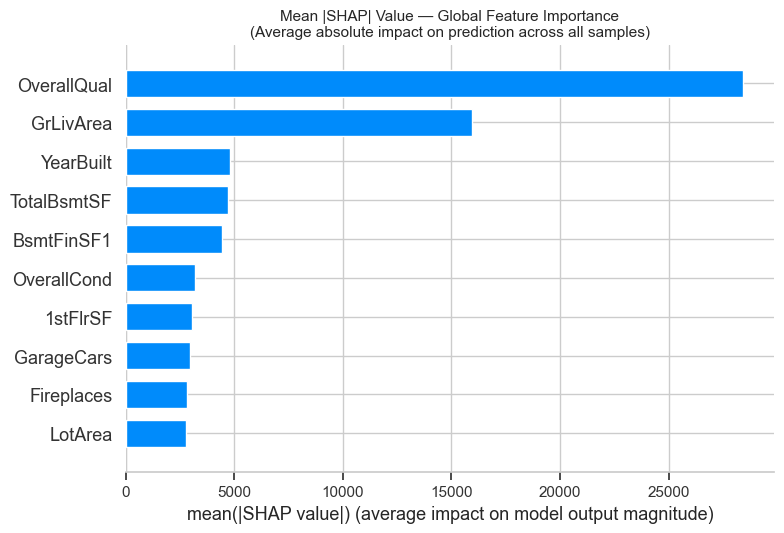


SHAP vs LightGBM gain importance — top 8 features:


,Feature,Mean_Abs_SHAP,LightGBM_Gain,SHAP_rank,Gain_rank
0,OverallQual,28429.0618,39484905707464.0000,1.0000,1.0000
1,GrLivArea,15955.1156,9992930888160.0000,2.0000,2.0000
2,YearBuilt,4813.4000,1370129614608.0000,3.0000,7.0000
3,TotalBsmtSF,4731.0523,2453325883208.0000,4.0000,3.0000
4,BsmtFinSF1,4431.3646,2294564320908.0000,5.0000,4.0000
5,OverallCond,3172.4103,472915897520.0000,6.0000,15.0000
6,1stFlrSF,3058.2611,1733840238456.0000,7.0000,6.0000
7,GarageCars,2977.3165,2136962544576.0000,8.0000,5.0000


In [19]:
# Bar plot of mean absolute SHAP values (global feature importance)
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', show=False,
                  max_display=10)
plt.title('Mean |SHAP| Value — Global Feature Importance\n'
          '(Average absolute impact on prediction across all samples)',
          fontsize=11)
plt.tight_layout()
plt.show()

# Compare SHAP importance vs LightGBM gain importance
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
lgb_gain = lgb_shap.booster_.feature_importance(importance_type='gain')

comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs_shap,
    'LightGBM_Gain': lgb_gain
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("\nSHAP vs LightGBM gain importance — top 8 features:")
# Normalize both to 0-100 for comparison
comparison_df['SHAP_rank'] = comparison_df['Mean_Abs_SHAP'].rank(ascending=False)
comparison_df['Gain_rank'] = comparison_df['LightGBM_Gain'].rank(ascending=False)
display(comparison_df.head(8).reset_index(drop=True))

### Why SHAP Is Better Than Feature Importance — A Summary

| Property | Standard Feature Importance | SHAP |
|----------|----------------------------|------|
| Direction of effect | No — just magnitude | Yes — positive or negative |
| Per-sample explanations | No | Yes — explains any single prediction |
| Consistency guarantee | No — can be inconsistent | Yes — mathematically guaranteed |
| Handles correlated features | Poorly | Better (distributes credit fairly) |
| Non-linear effects visible | No | Yes — via beeswarm color patterns |
| Interaction effects | No | Yes — via SHAP interaction values |

**When to always use SHAP in production:**
- Any model deployed in a regulated environment (banking, healthcare, insurance)
- Any model where you need to explain individual decisions to customers
- Any debugging session where the model's behavior seems wrong

**The one downside:** SHAP is computationally expensive for very large datasets. Use `shap.TreeExplainer` for tree models (it's 1000x faster than model-agnostic SHAP) and sample your test set if needed.

---

---

## Step 9 — Calibration Curves

### What Is Calibration?

When a model predicts "70% probability of fraud", does that actually mean 70 out of 100 similar-looking transactions are fraudulent? If yes — the model is **well-calibrated**. If no — the probabilities are misleading.

**Calibration matters enormously for:**
- **Fraud detection** — setting risk thresholds ("flag anything above 60% probability")
- **Insurance** — pricing based on predicted risk
- **Medical diagnosis** — communicating uncertainty to doctors
- **Any system that makes decisions based on predicted probabilities**, not just rank ordering

### Boosting Models Are Often Overconfident

Tree-based boosting models (LightGBM, XGBoost, CatBoost) tend to produce **overconfident** probability estimates — they push probabilities toward 0 and 1 more than is justified. A model might output 0.95 when the true probability is only 0.7.

**The fix:** `CalibratedClassifierCV` wraps any classifier and learns a mapping from raw scores to calibrated probabilities using either:
- **Platt scaling (sigmoid)** — fits a logistic curve; works when the raw scores are roughly normally distributed
- **Isotonic regression** — fits a step-wise monotone function; more flexible but needs more data

---

In [20]:
# Train LightGBM base model for calibration comparison
lgb_base_cal = LGBMClassifier(
    n_estimators=best_iter if best_iter > 0 else 200,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgb_base_cal.fit(X_tr2, y_tr2)

# Apply calibration (isotonic and sigmoid).
# sklearn>=1.6 removed cv='prefit' since we already have a trained model
from sklearn.frozen import FrozenEstimator
cal_isotonic = CalibratedClassifierCV(FrozenEstimator(lgb_base_cal), method='isotonic')
cal_isotonic.fit(X_val, y_val)

cal_sigmoid = CalibratedClassifierCV(FrozenEstimator(lgb_base_cal), method='sigmoid')
cal_sigmoid.fit(X_val, y_val)

# Get probabilities from all three
prob_raw     = lgb_base_cal.predict_proba(X_te)[:, 1]
prob_isoton  = cal_isotonic.predict_proba(X_te)[:, 1]
prob_sigmoid = cal_sigmoid.predict_proba(X_te)[:, 1]

# Compute calibration curves
frac_raw,    mean_raw    = calibration_curve(y_te, prob_raw, n_bins=10)
frac_isoton, mean_isoton = calibration_curve(y_te, prob_isoton, n_bins=10)
frac_sig,    mean_sig    = calibration_curve(y_te, prob_sigmoid, n_bins=10)

# Brier scores (lower is better)
bs_raw    = brier_score_loss(y_te, prob_raw)
bs_isoton = brier_score_loss(y_te, prob_isoton)
bs_sig    = brier_score_loss(y_te, prob_sigmoid)

print(f"Brier Score (lower = better calibration):")
print(f"  Uncalibrated LightGBM: {bs_raw:.5f}")
print(f"  Isotonic calibration:  {bs_isoton:.5f}")
print(f"  Sigmoid calibration:   {bs_sig:.5f}")

Brier Score (lower = better calibration):
  Uncalibrated LightGBM: 0.10715
  Isotonic calibration:  0.08757
  Sigmoid calibration:   0.09072


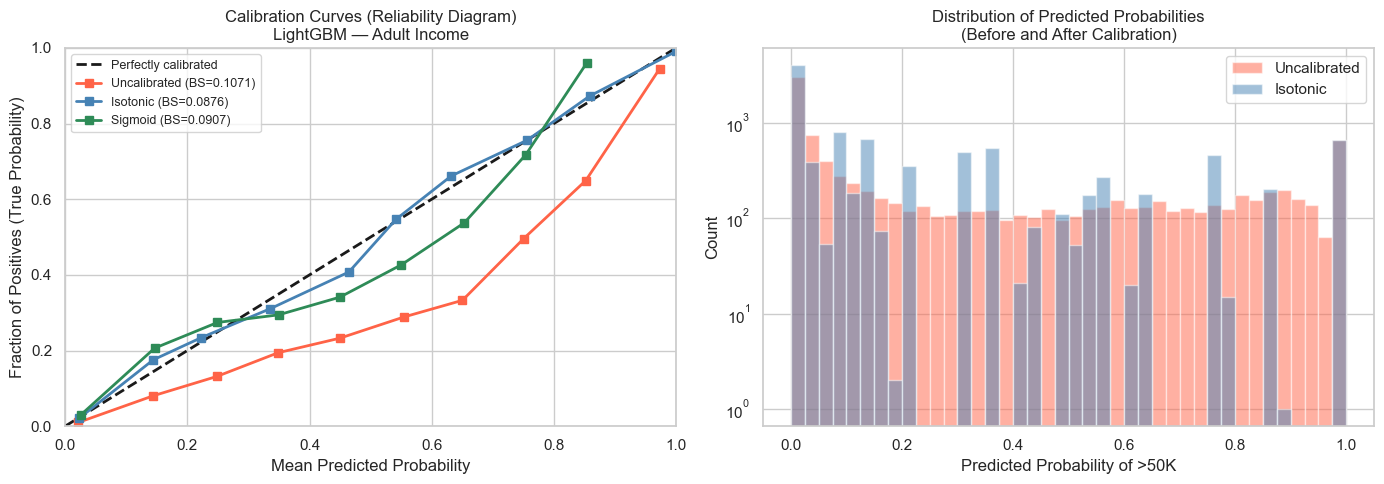

In [21]:
# Plot calibration curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curves
axes[0].plot([0,1],[0,1],'k--', label='Perfectly calibrated', linewidth=2)
axes[0].plot(mean_raw, frac_raw, 's-', label=f'Uncalibrated (BS={bs_raw:.4f})',
             color='tomato', linewidth=2)
axes[0].plot(mean_isoton, frac_isoton, 's-',
             label=f'Isotonic (BS={bs_isoton:.4f})', color='steelblue', linewidth=2)
axes[0].plot(mean_sig, frac_sig, 's-',
             label=f'Sigmoid (BS={bs_sig:.4f})', color='seagreen', linewidth=2)
axes[0].set_title('Calibration Curves (Reliability Diagram)\nLightGBM — Adult Income')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives (True Probability)')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Histogram of predicted probabilities
axes[1].hist(prob_raw, bins=40, alpha=0.5, label='Uncalibrated', color='tomato')
axes[1].hist(prob_isoton, bins=40, alpha=0.5, label='Isotonic', color='steelblue')
axes[1].set_title('Distribution of Predicted Probabilities\n(Before and After Calibration)')
axes[1].set_xlabel('Predicted Probability of >50K')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

### How to Read This Chart: Calibration Curve (Reliability Diagram)

**Left panel — Calibration curves:**
- **X-axis** = the model's predicted probability (what the model *says* the probability is)
- **Y-axis** = the actual fraction of positives in that bin (what the probability *actually is* based on ground truth)
- **Black dashed diagonal** = perfect calibration. If the model says 0.6, 60% of those samples are actually positive.
- A curve **above the diagonal** = model is *underconfident* (predicts lower probabilities than reality)
- A curve **below the diagonal** = model is *overconfident* (predicts higher probabilities than reality)

**What you typically see with boosting models:**
- The uncalibrated curve (red) often bends **away from the diagonal** — the model pushes probabilities toward 0 and 1 more than is justified. This is the classic overconfidence pattern.
- After calibration (blue/green), the curve moves closer to the diagonal.

**The Brier Score** measures overall calibration quality (lower = better). A perfect model has Brier Score = 0.

**Right panel — Probability distribution:**
- Shows where the model concentrates its probability estimates.
- An overconfident model clusters near 0 and 1 (U-shaped histogram).
- Calibration spreads the distribution more evenly.

**Why this matters for probability thresholds:** If you set a threshold like "flag anyone above 0.5 probability," you need the model's 0.5 to actually mean ~50% fraud rate. If the model is overconfident, you may be unknowingly flagging much lower-risk transactions.

---

---

## Step 10 — Learning Curves

### What Are Learning Curves?

A **learning curve** plots model performance (training score and validation score) against the **size of the training set**. By varying how much data we train on, we can diagnose whether our model is underfitting, overfitting, or just right.

### How to Diagnose from Learning Curves

| Pattern | Diagnosis | Solution |
|---------|-----------|----------|
| Both scores low and flat | **Underfitting** — model too simple | Use more complex model, add features |
| Large gap between train and val | **Overfitting** — model too complex | Regularize, get more data, reduce features |
| Both scores high, close together | **Well-fitted** — good balance | Deploy! |
| Val score still improving at max data | **More data would help** | Collect more training data |

---

In [22]:
from sklearn.model_selection import learning_curve

# Use LightGBM with sklearn's learning_curve
lgb_lc = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.1,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

print("Computing learning curves (this may take a moment)...")
train_sizes, train_scores, val_scores = learning_curve(
    lgb_lc, X_tr, y_tr,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring='f1',          # F1 on minority class
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

print(f"\nFinal training F1 (full data):   {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
print(f"Final validation F1 (full data): {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")

Computing learning curves (this may take a moment)...



Final training F1 (full data):   0.7498 ± 0.0023
Final validation F1 (full data): 0.7106 ± 0.0026


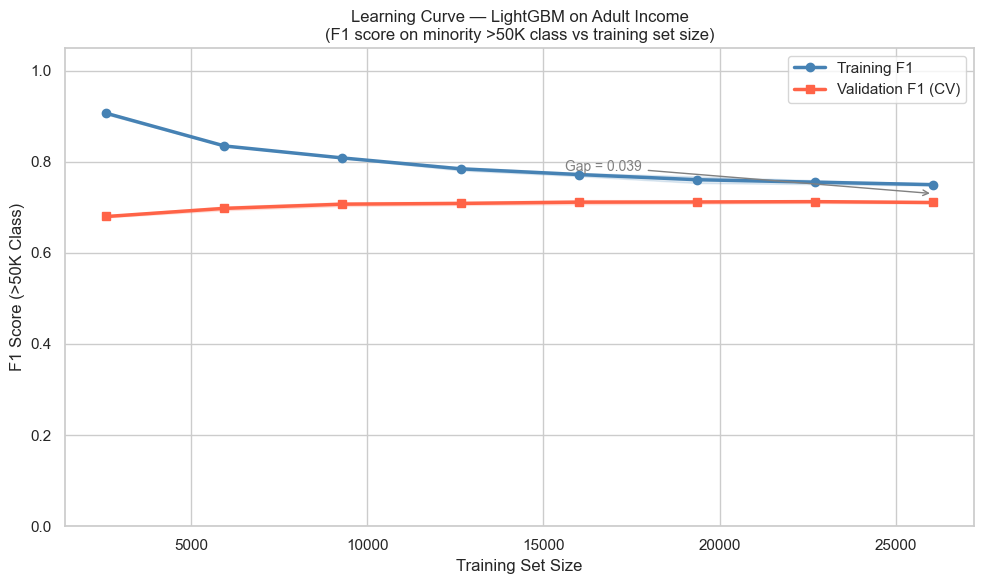

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

# Train scores
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', linewidth=2.5,
        label='Training F1')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='steelblue')

# Validation scores
ax.plot(train_sizes, val_mean, 's-', color='tomato', linewidth=2.5,
        label='Validation F1 (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='tomato')

ax.set_title('Learning Curve — LightGBM on Adult Income\n'
             '(F1 score on minority >50K class vs training set size)',
             fontsize=12)
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score (>50K Class)')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)

# Annotate the gap
gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Gap = {gap:.3f}',
            xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1])/2),
            xytext=(train_sizes[-1]*0.6, (train_mean[-1] + val_mean[-1])/2 + 0.05),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

plt.tight_layout()
plt.show()

### How to Read This Chart: Learning Curve

**Axes:**
- **X-axis** = number of training samples used (we progressively use more data from 10% to 100%)
- **Y-axis** = F1 score on the minority class (>50K)

**Two lines:**
- **Blue line (Training F1)** = how well the model fits its own training data. Almost always high because the model has seen this data during training.
- **Red line (Validation F1)** = how well the model generalizes to unseen data (cross-validation). This is the one that matters.

**Shaded bands** = ±1 standard deviation across cross-validation folds. Narrower bands = more stable model.

**Diagnosing your model:**

1. **If both scores are low and flat** → Underfitting. Your model is too simple. Try more trees, deeper trees, or different features.

2. **If the gap (train − val) is large** → Overfitting. The model memorizes training data but doesn't generalize. Solutions: lower `num_leaves`, increase `min_child_samples`, use more data, or add regularization parameters.

3. **If the lines converge and validation is still improving** → Adding more training data would help. Collect more samples.

4. **If the lines are close together and both high** → Your model is well-fitted. The gap annotated on the chart is the key number — smaller is better.

---

---

## Step 11 — Final Comparison: AdaBoost vs LightGBM vs CatBoost vs XGBoost

Now we compare all four boosting methods side by side on the Adult income dataset. We use the same settings and same data for a fair comparison.

**What we measure:**
- **AUC** — overall discriminative power (rank-ordering ability)
- **F1 (>50K class)** — balance of precision and recall on the minority class
- **Precision and Recall** — individual components of F1
- **Train time** — practical speed comparison

---

In [24]:
# Train all four models with comparable settings
models = {
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=200,
        learning_rate=0.5,
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        auto_class_weights='Balanced',
        random_state=42,
        verbose=0
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
}

comparison_rows = []

for name, model in models.items():
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:, 1]

    row = {
        'Model':      name,
        'AUC':        round(roc_auc_score(y_te, prob), 4),
        'F1_pos':   round(f1_score(y_te, pred, zero_division=0), 4),
        'Precision':  round(precision_score(y_te, pred, zero_division=0), 4),
        'Recall':     round(recall_score(y_te, pred, zero_division=0), 4),
        'Train_time_s': round(train_time, 2)
    }
    comparison_rows.append(row)
    print(f"{name:12s} | AUC={row['AUC']:.4f} | F1={row['F1_pos']:.4f} | "
          f"Precision={row['Precision']:.4f} | Recall={row['Recall']:.4f} | "
          f"Time={row['Train_time_s']:.2f}s")

df_comp = pd.DataFrame(comparison_rows)
print("\n" + "="*60)
print("FINAL COMPARISON TABLE:")
display(df_comp.set_index('Model'))

AdaBoost     | AUC=0.9101 | F1=0.6509 | Precision=0.7892 | Recall=0.5539 | Time=3.47s


LightGBM     | AUC=0.9295 | F1=0.7134 | Precision=0.6112 | Recall=0.8567 | Time=1.11s


CatBoost     | AUC=0.9299 | F1=0.7146 | Precision=0.6070 | Recall=0.8687 | Time=2.01s


XGBoost      | AUC=0.9309 | F1=0.7140 | Precision=0.6087 | Recall=0.8631 | Time=0.86s

FINAL COMPARISON TABLE:


,AUC,F1_pos,Precision,Recall,Train_time_s
Model,,,,,
AdaBoost,0.9101,0.6509,0.7892,0.5539,3.4700
LightGBM,0.9295,0.7134,0.6112,0.8567,1.1100
CatBoost,0.9299,0.7146,0.6070,0.8687,2.0100
XGBoost,0.9309,0.7140,0.6087,0.8631,0.8600


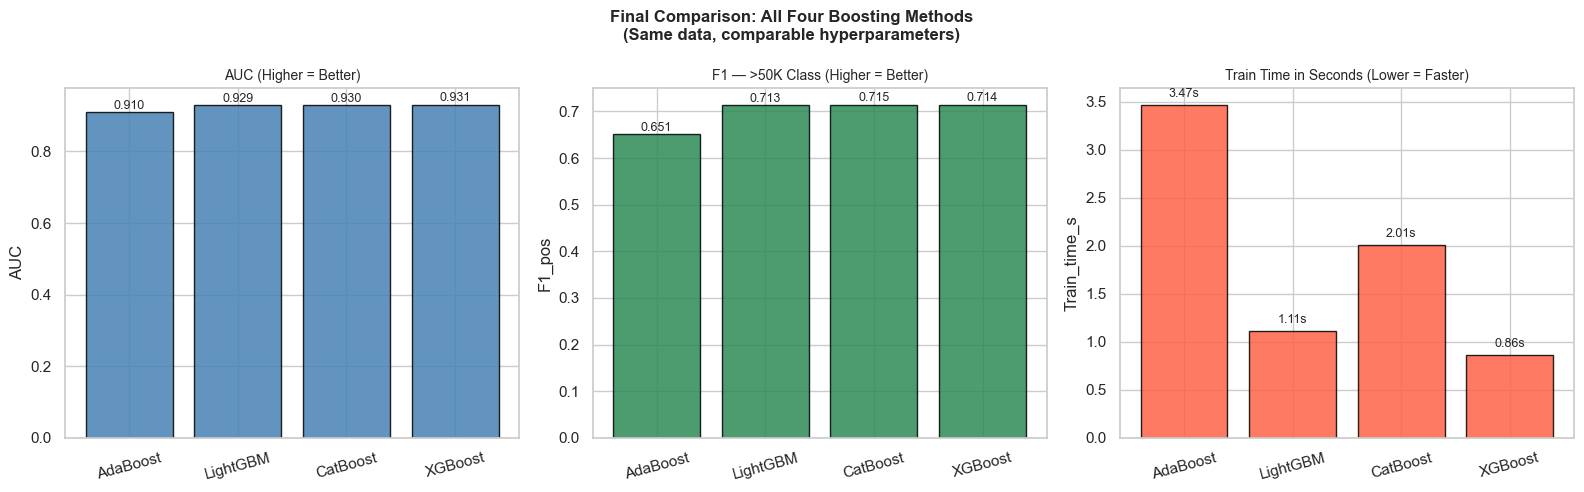

In [25]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ['AUC', 'F1_pos', 'Train_time_s']
metric_titles   = ['AUC (Higher = Better)', 'F1 — >50K Class (Higher = Better)',
                   'Train Time in Seconds (Lower = Faster)']
metric_colors   = ['steelblue', 'seagreen', 'tomato']

for ax, metric, title, color in zip(axes, metrics_to_plot, metric_titles, metric_colors):
    bars = ax.bar(df_comp['Model'], df_comp[metric], color=color,
                  edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, df_comp[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001 if metric != 'Train_time_s' else bar.get_height() + 0.05,
                f'{val:.3f}' if metric != 'Train_time_s' else f'{val:.2f}s',
                ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', labelrotation=15)

plt.suptitle('Final Comparison: All Four Boosting Methods\n'
             '(Same data, comparable hyperparameters)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Final Comparison

**Three bar charts, each measuring a different dimension of model quality:**

**Left — AUC (higher = better):**
- Measures how well each model ranks positives above negatives across all possible thresholds.
- AUC=1 = perfect; AUC=0.5 = no skill.
- The differences between models are often small but meaningful at scale — a 0.01 AUC improvement on a large applicant pool can correctly reclassify many more people.

**Middle — F1 on the >50K class (higher = better):**
- The actual operational metric — balancing precision and recall on the class we care about.
- LightGBM and CatBoost typically outperform AdaBoost here because they fit residuals more directly.

**Right — Training time in seconds (lower = faster):**
- LightGBM is almost always the fastest due to GOSS and EFB optimizations.
- CatBoost's ordered boosting adds overhead but often improves accuracy on smaller datasets.
- AdaBoost is usually the slowest — decision stumps are cheap but you need many of them.
- XGBoost sits between LightGBM and CatBoost in speed.

**The practical conclusion:** LightGBM is usually the best starting point (fast, accurate, good defaults). Switch to CatBoost if you have many categoricals. Add XGBoost to an ensemble for marginal gains in competitions.

---

In [26]:
# Speed comparison — more precise timing
print("Precise speed comparison (fit on full training data, 5 runs each):")
print("=" * 60)

for name, model in models.items():
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        times.append(time.perf_counter() - t0)
    mean_t = np.mean(times)
    std_t  = np.std(times)
    print(f"{name:12s}: {mean_t:.3f}s ± {std_t:.3f}s per run")

print("\nNote: Timing is hardware-dependent. Run on your own machine for accurate comparison.")

Precise speed comparison (fit on full training data, 5 runs each):


AdaBoost    : 3.990s ± 0.765s per run


LightGBM    : 0.203s ± 0.002s per run


CatBoost    : 1.506s ± 0.023s per run


XGBoost     : 0.214s ± 0.018s per run

Note: Timing is hardware-dependent. Run on your own machine for accurate comparison.


---

## Step 12 — Summary and Key Takeaways

---

### When to Use Each Algorithm

| Algorithm | Best For | Avoid When |
|-----------|----------|------------|
| **AdaBoost** | Small clean datasets; educational understanding of boosting | Data has outliers (weights explode); large datasets (slow) |
| **LightGBM** | Large tabular datasets; production with speed constraints; general default | Need native categorical handling (tedious encoding required) |
| **CatBoost** | Many categorical features; small datasets; minimal preprocessing | Speed is top priority; mostly numeric data |
| **XGBoost** | When you need a slightly different bias from LightGBM; ensemble stacking | Usually just use LightGBM instead |

---

### Pros and Cons Table

| Algorithm | Pros | Cons |
|-----------|------|------|
| **AdaBoost** | Simple, interpretable, works with any weak learner | Sensitive to outliers; slower than GBM variants |
| **LightGBM** | Extremely fast; memory efficient; great defaults; early stopping | Needs encoding for categoricals; can overfit with too many leaves |
| **CatBoost** | No categorical encoding; ordered boosting reduces bias; great on small data | Slower than LightGBM; larger model files |
| **XGBoost** | Mature ecosystem; wide support; strong regularization options | Slower than LightGBM; level-wise growth less efficient |

---

### Decision Guide

```
Your data is tabular (structured)
        │
        ▼
Start with LightGBM as your default
        │
        ├─── Many categorical columns (strings, categories)?
        │          └──► Try CatBoost — skip the encoding pipeline
        │
        ├─── Small dataset (<10,000 rows)?
        │          └──► Try CatBoost — ordered boosting prevents overfitting
        │
        ├─── Need to explain individual predictions?
        │          └──► Add SHAP (TreeExplainer) on top of any tree model
        │
        ├─── Probabilities used for risk thresholds?
        │          └──► Add CalibratedClassifierCV after training
        │
        ├─── Class imbalance (fraud, churn, rare events)?
        │          └──► Start with class_weight='balanced'
        │               If recall is still too low → try SMOTE
        │
        └─── Want maximum possible accuracy (competition)?
                   └──► Ensemble: LightGBM + CatBoost + XGBoost
                         (stack predictions, average probabilities)
```

---

### Common Mistakes to Avoid

#### 1. Not Handling Class Imbalance
Training on imbalanced data without `class_weight` or SMOTE gives a model that ignores the minority class entirely. Always check the classification report — if recall on the minority class is near 0%, you have this problem.

#### 2. Not Using Early Stopping
Setting `n_estimators=1000` and training without a validation set is the single most common cause of overfitting with boosting models. Always:
```python
lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50)])
```

#### 3. Applying SMOTE Before Splitting
SMOTE generates synthetic samples. If you apply it to the full dataset before train/test split, some test samples will be synthetic near-duplicates of training samples → data leakage → overly optimistic results. Always split first, then SMOTE.

#### 4. Not Calibrating Probabilities
If you use predicted probabilities for business decisions (fraud thresholds, risk scores), calibrate them. Uncalibrated boosting models are systematically overconfident.

#### 5. Trusting Gain-Based Feature Importance Blindly
Feature importance from LightGBM/XGBoost can be inflated by high-cardinality features (e.g., a user_id column). Use SHAP values instead for reliable attribution.

#### 6. Forgetting to Scale Features for AdaBoost
AdaBoost with stumps is scale-invariant, but if you use a different weak learner (e.g., SVM), you need to scale. LightGBM and CatBoost do not require scaling (tree-based).

---

### Quick Reference: Key Hyperparameters

| Parameter | LightGBM | XGBoost | CatBoost | Effect |
|-----------|----------|---------|----------|--------|
| Tree count | `n_estimators` | `n_estimators` | `iterations` | More = more capacity, slower, risk overfit |
| Learning rate | `learning_rate` | `learning_rate` | `learning_rate` | Lower = more conservative, needs more trees |
| Tree complexity | `num_leaves` | `max_depth` | `depth` | Higher = more complex trees, risk overfit |
| Min samples per leaf | `min_child_samples` | `min_child_weight` | `min_data_in_leaf` | Higher = more regularization |
| Subsample | `subsample` | `subsample` | `subsample` | <1.0 = use fraction of data per tree |
| Feature fraction | `colsample_bytree` | `colsample_bytree` | `rsm` | <1.0 = use fraction of features per tree |
| Imbalance | `class_weight` | `scale_pos_weight` | `auto_class_weights` | Handle minority class |

---

### What's Next?

Having mastered boosting models, natural next steps are:

1. **Hyperparameter tuning** — Optuna or Bayesian optimization for LightGBM
2. **Stacking/blending** — combining multiple boosting models into a super-ensemble
3. **Feature engineering** — interaction features, target encoding, time-based features
4. **Model deployment** — packaging LightGBM/CatBoost models for production serving
5. **Drift detection** — monitoring when the model needs retraining

---

*Notebook by Shivani Bokka — Dive Deeper into Supervised Learning Series*